# Notebook 02: Baseline Similarity
**Ship of Theseus — Computational Forensics Project**

Compute Baseline BLEU/ROUGE/BERTScore across T0 → T3.

In [2]:
%load_ext autoreload
%autoreload 2
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from pathlib import Path

ROOT = Path().resolve().parents[0]
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

FIGURES = ROOT / "figures" / "baseline_similarity"
EXP_DATA = ROOT / "experiments" / "baseline_similarity"
STAGES = ['T0', 'T1', 'T2', 'T3']

print(f"Project root: {ROOT}")

Project root: C:\Users\cnguy\Documents\CS6120\ShipOfTheseus-NLP


## Load Chain Data
T0 → T3 Chains were built and saved in Notebook 01. Load directly from `data/processed/`

In [4]:
from src.utils.config import DATA_PROCESSED, DATASETS
chains = {}
for name in DATASETS.keys():
    path = DATA_PROCESSED / f"{name}_chains.csv"
    chains[name] = pd.read_csv(path)
    print(f"Loaded '{name}': {chains[name].shape}")

print(f"\nColumns: {chains['wp'].columns.tolist()}")

Loaded 'sci_gen': (19506, 16)
Loaded 'wp': (18604, 16)
Loaded 'xsum': (22405, 16)
Loaded 'eli5': (22053, 16)
Loaded 'cmv': (11271, 16)
Loaded 'tldr': (17058, 16)
Loaded 'yelp': (23196, 16)

Columns: ['source', 'key', 'paraphraser', 'family', 'T0_text', 'T0_cleaned', 'T0_no_stop', 'T1_text', 'T1_cleaned', 'T1_no_stop', 'T2_text', 'T2_cleaned', 'T2_no_stop', 'T3_text', 'T3_cleaned', 'T3_no_stop']


## Compute BLEU & ROUGE
BLEU/ROUGE are lexical, not semantic. It is used here only to quantify surface-form change. Do not interpret it as a semantic metric.

In [17]:
from src.similarity.bleu_rouge import compute_bleu_rouge, mean_scores_by_stage

scored_lexical = {}
for name, df in chains.items():
    print(f"\nComputing BLEU/ROUGE for '{name}'...")
    df = df.sample(1000, random_state=19)
    scored_lexical[name] = compute_bleu_rouge(df)

# Quick look at wp
score_cols = [c for c in scored_lexical['wp'].columns if any(
    c.startswith(m) for m in ['bleu', 'rouge'])]
scored_lexical['wp'][['source', 'key', 'paraphraser'] + score_cols].head()


Computing BLEU/ROUGE for 'sci_gen'...
  T1: BLEU=0.5317  ROUGE-L=0.6099  (1000 rows)
  T2: BLEU=0.4496  ROUGE-L=0.5467  (1000 rows)
  T3: BLEU=0.3919  ROUGE-L=0.4935  (944 rows)

Computing BLEU/ROUGE for 'wp'...
  T1: BLEU=0.5089  ROUGE-L=0.5759  (1000 rows)
  T2: BLEU=0.4273  ROUGE-L=0.5068  (996 rows)
  T3: BLEU=0.3750  ROUGE-L=0.4585  (995 rows)

Computing BLEU/ROUGE for 'xsum'...
  T1: BLEU=0.5012  ROUGE-L=0.5598  (1000 rows)
  T2: BLEU=0.4169  ROUGE-L=0.4975  (1000 rows)
  T3: BLEU=0.3699  ROUGE-L=0.4536  (1000 rows)

Computing BLEU/ROUGE for 'eli5'...
  T1: BLEU=0.4669  ROUGE-L=0.5430  (1000 rows)
  T2: BLEU=0.3883  ROUGE-L=0.4777  (998 rows)
  T3: BLEU=0.3430  ROUGE-L=0.4363  (997 rows)

Computing BLEU/ROUGE for 'cmv'...
  T1: BLEU=0.5053  ROUGE-L=0.5649  (1000 rows)
  T2: BLEU=0.4216  ROUGE-L=0.5014  (1000 rows)
  T3: BLEU=0.3749  ROUGE-L=0.4562  (997 rows)

Computing BLEU/ROUGE for 'tldr'...
  T1: BLEU=0.5299  ROUGE-L=0.5927  (1000 rows)
  T2: BLEU=0.4524  ROUGE-L=0.5344  (99

,source,key,paraphraser,rouge1_T1,rouge2_T1,rougeL_T1,bleu_T1,rouge1_T2,rouge2_T2,rougeL_T2,bleu_T2,rouge1_T3,rouge2_T3,rougeL_T3,bleu_T3
3266,Eleuther-AI,wp-510,dipper(high),0.208226,0.007732,0.051414,0.007130,0.141919,0.005270,0.036794,0.002657,0.063253,0.003021,0.030120,0.000021
2028,BigScience,wp-675,chatgpt,0.502591,0.197917,0.409326,0.272841,0.470588,0.169666,0.347826,0.247480,0.479592,0.184615,0.367347,0.260162
2795,BigScience,wp-9533,pegasus(slight),0.960227,0.925714,0.920455,0.916190,0.868805,0.774194,0.810496,0.763387,0.525458,0.429448,0.468432,0.605084
10392,LLAMA,wp-687,pegasus(full),0.822776,0.632929,0.698932,0.656766,0.735207,0.509630,0.622781,0.534784,0.722097,0.490623,0.597753,0.509882
10505,LLAMA,wp-705,chatgpt,0.625000,0.339806,0.461538,0.463960,0.586538,0.271845,0.394231,0.401447,0.481132,0.190476,0.358491,0.311490


## Compute BERTScore
BERTScore uses contextual embeddings and should stay higher than BLEU/ROUGE.

**DO NOT RUN THIS CELL** Broke my motherboard :(

In [ ]:
from src.similarity.bertscore import compute_bertscore, mean_bertscore_by_stage
"""
scored_all = {}

for name, df in scored_lexical.items():
    print(f"\nComputing BERTScore for '{name}'...")
    df = df.sample(1000, random_state=271)
    scored_all[name] = compute_bertscore(df)


# Quick look at wp
bert_cols = [c for c in scored_all['wp'].columns if c.startswith('bertscore')]
scored_all['wp'][['source', 'key', 'paraphraser'] + bert_cols].head()
"""


Computing BERTScore for 'sci_gen'...
BERTScore device: cpu


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

C:\Users\cnguy\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\cnguy\.cache\huggingface\hub\models--roberta-large. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Computing BERTScore for 'wp'...
BERTScore device: cpu


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## Load Data Computed on Google Colab Instead
Contains both BLEU/ROUGE and BERTScore

In [6]:
scores = {}
for name in DATASETS.keys():
    path = EXP_DATA / f"{name}_chains_scored.csv"
    scores[name] = pd.read_csv(path)
    print(f"Loaded {name} Scores")
print(f"Columns: {scores['wp'].columns.tolist()}")

Loaded sci_gen Scores
Loaded wp Scores
Loaded xsum Scores
Loaded eli5 Scores
Loaded cmv Scores
Loaded tldr Scores
Loaded yelp Scores
Columns: ['source', 'key', 'paraphraser', 'family', 'T0_text', 'T0_cleaned', 'T0_no_stop', 'T1_text', 'T1_cleaned', 'T1_no_stop', 'T2_text', 'T2_cleaned', 'T2_no_stop', 'T3_text', 'T3_cleaned', 'T3_no_stop', 'rouge1_T1', 'rouge2_T1', 'rougeL_T1', 'bleu_T1', 'rouge1_T2', 'rouge2_T2', 'rougeL_T2', 'bleu_T2', 'rouge1_T3', 'rouge2_T3', 'rougeL_T3', 'bleu_T3', 'bertscore_T1', 'bertscore_T2', 'bertscore_T3']


## Mean Scores Per Stage

In [11]:
from src.similarity.bleu_rouge import mean_scores_by_stage as mean_lex_scores
from src.similarity.bertscore import mean_bertscore_by_stage as mean_bertscore

summary_tables = {}
for name, df in scores.items():
    lex   = mean_lex_scores(df)
    bert  = mean_bertscore(df)
    combined = pd.concat([lex, bert], ignore_index=True)
    pivot = combined.pivot(index='metric', columns='stage', values='score').round(4)
    summary_tables[name] = pivot
    print("=" * 80)
    print(f"DATASET: {name}")
    print(pivot.to_string())
    print("=" * 80)
    print("\n")

DATASET: sci_gen
stage             T1      T2      T3
metric                              
BERTSCORE-F1  0.9216  0.9100  0.9008
BLEU-2        0.5253  0.4438  0.3877
ROUGE-1       0.6953  0.6358  0.5900
ROUGE-2       0.5317  0.4570  0.4031
ROUGE-L       0.6033  0.5411  0.4887


DATASET: wp
stage             T1      T2      T3
metric                              
BERTSCORE-F1  0.9132  0.8997  0.8909
BLEU-2        0.5055  0.4248  0.3718
ROUGE-1       0.6879  0.6224  0.5770
ROUGE-2       0.4896  0.4097  0.3629
ROUGE-L       0.5715  0.5026  0.4543


DATASET: xsum
stage             T1      T2      T3
metric                              
BERTSCORE-F1  0.9237  0.9125  0.9058
BLEU-2        0.5048  0.4202  0.3748
ROUGE-1       0.6839  0.6213  0.5819
ROUGE-2       0.4942  0.4129  0.3702
ROUGE-L       0.5647  0.5018  0.4603


DATASET: eli5
stage             T1      T2      T3
metric                              
BERTSCORE-F1  0.9170  0.9063  0.8997
BLEU-2        0.4811  0.4017  0.3582
ROUGE-1     

## Mean Scores Per Stage Per Paraphraser

In [13]:
from src.similarity.bleu_rouge import mean_scores_by_stage as mean_lex_scores
from src.similarity.bertscore import mean_bertscore_by_stage as mean_bertscore

summary_tables = {}

for name, df in scores.items():
    print("=" * 80)
    print(f"DATASET: {name}")
    print("=" * 80)

    for paraphraser, group_df in df.groupby("paraphraser"):
        lex     = mean_lex_scores(group_df)
        bert    = mean_bertscore(group_df)
        combined = pd.concat([lex, bert], ignore_index=True)

        # Fix: values='score' not values='metric'
        pivot = combined.pivot(index='metric', columns='stage', values='score').round(4)

        print(f"\n  Paraphraser: {paraphraser} ({len(group_df):,} rows)")
        print(pivot.to_string())

    # Also store the full per-paraphraser breakdown for this dataset
    summary_tables[name] = {}
    for paraphraser, group_df in df.groupby("paraphraser"):
        lex      = mean_lex_scores(group_df)
        bert     = mean_bertscore(group_df)
        combined = pd.concat([lex, bert], ignore_index=True)
        summary_tables[name][paraphraser] = (
            combined.pivot(index='metric', columns='stage', values='score').round(4)
        )

    print("\n")

DATASET: sci_gen

  Paraphraser: chatgpt (62 rows)
stage             T1      T2      T3
metric                              
BERTSCORE-F1  0.9283  0.9166  0.9112
BLEU-2        0.4303  0.3725  0.3313
ROUGE-1       0.6733  0.6323  0.5990
ROUGE-2       0.4304  0.3706  0.3300
ROUGE-L       0.5705  0.5082  0.4685

  Paraphraser: dipper (68 rows)
stage             T1      T2      T3
metric                              
BERTSCORE-F1  0.8980  0.8831  0.8704
BLEU-2        0.3359  0.2311  0.1795
ROUGE-1       0.5848  0.4955  0.4396
ROUGE-2       0.2719  0.1788  0.1347
ROUGE-L       0.3591  0.2917  0.2430

  Paraphraser: dipper(high) (72 rows)
stage             T1      T2      T3
metric                              
BERTSCORE-F1  0.7964  0.7955  0.7972
BLEU-2        0.0443  0.0186  0.0109
ROUGE-1       0.1907  0.1424  0.1136
ROUGE-2       0.0177  0.0082  0.0074
ROUGE-L       0.1140  0.0922  0.0776

  Paraphraser: dipper(low) (70 rows)
stage             T1      T2      T3
metric                   

---
## Figures
Each figure is saved to `figures/baseline_similarity/`.

## Lexical vs. Semantic Decay Per Data Set

In [31]:
for name, df in scores.items():
    print(name, [c for c in df.columns if 'bert' in c.lower()])

sci_gen ['bertscore_T1', 'bertscore_T2', 'bertscore_T3']
wp ['bertscore_T1', 'bertscore_T2', 'bertscore_T3']
xsum ['bertscore_T1', 'bertscore_T2', 'bertscore_T3']
eli5 ['bertscore_T1', 'bertscore_T2', 'bertscore_T3']
cmv ['bertscore_T1', 'bertscore_T2', 'bertscore_T3']
tldr ['bertscore_T1', 'bertscore_T2', 'bertscore_T3']
yelp ['bertscore_T1', 'bertscore_T2', 'bertscore_T3']


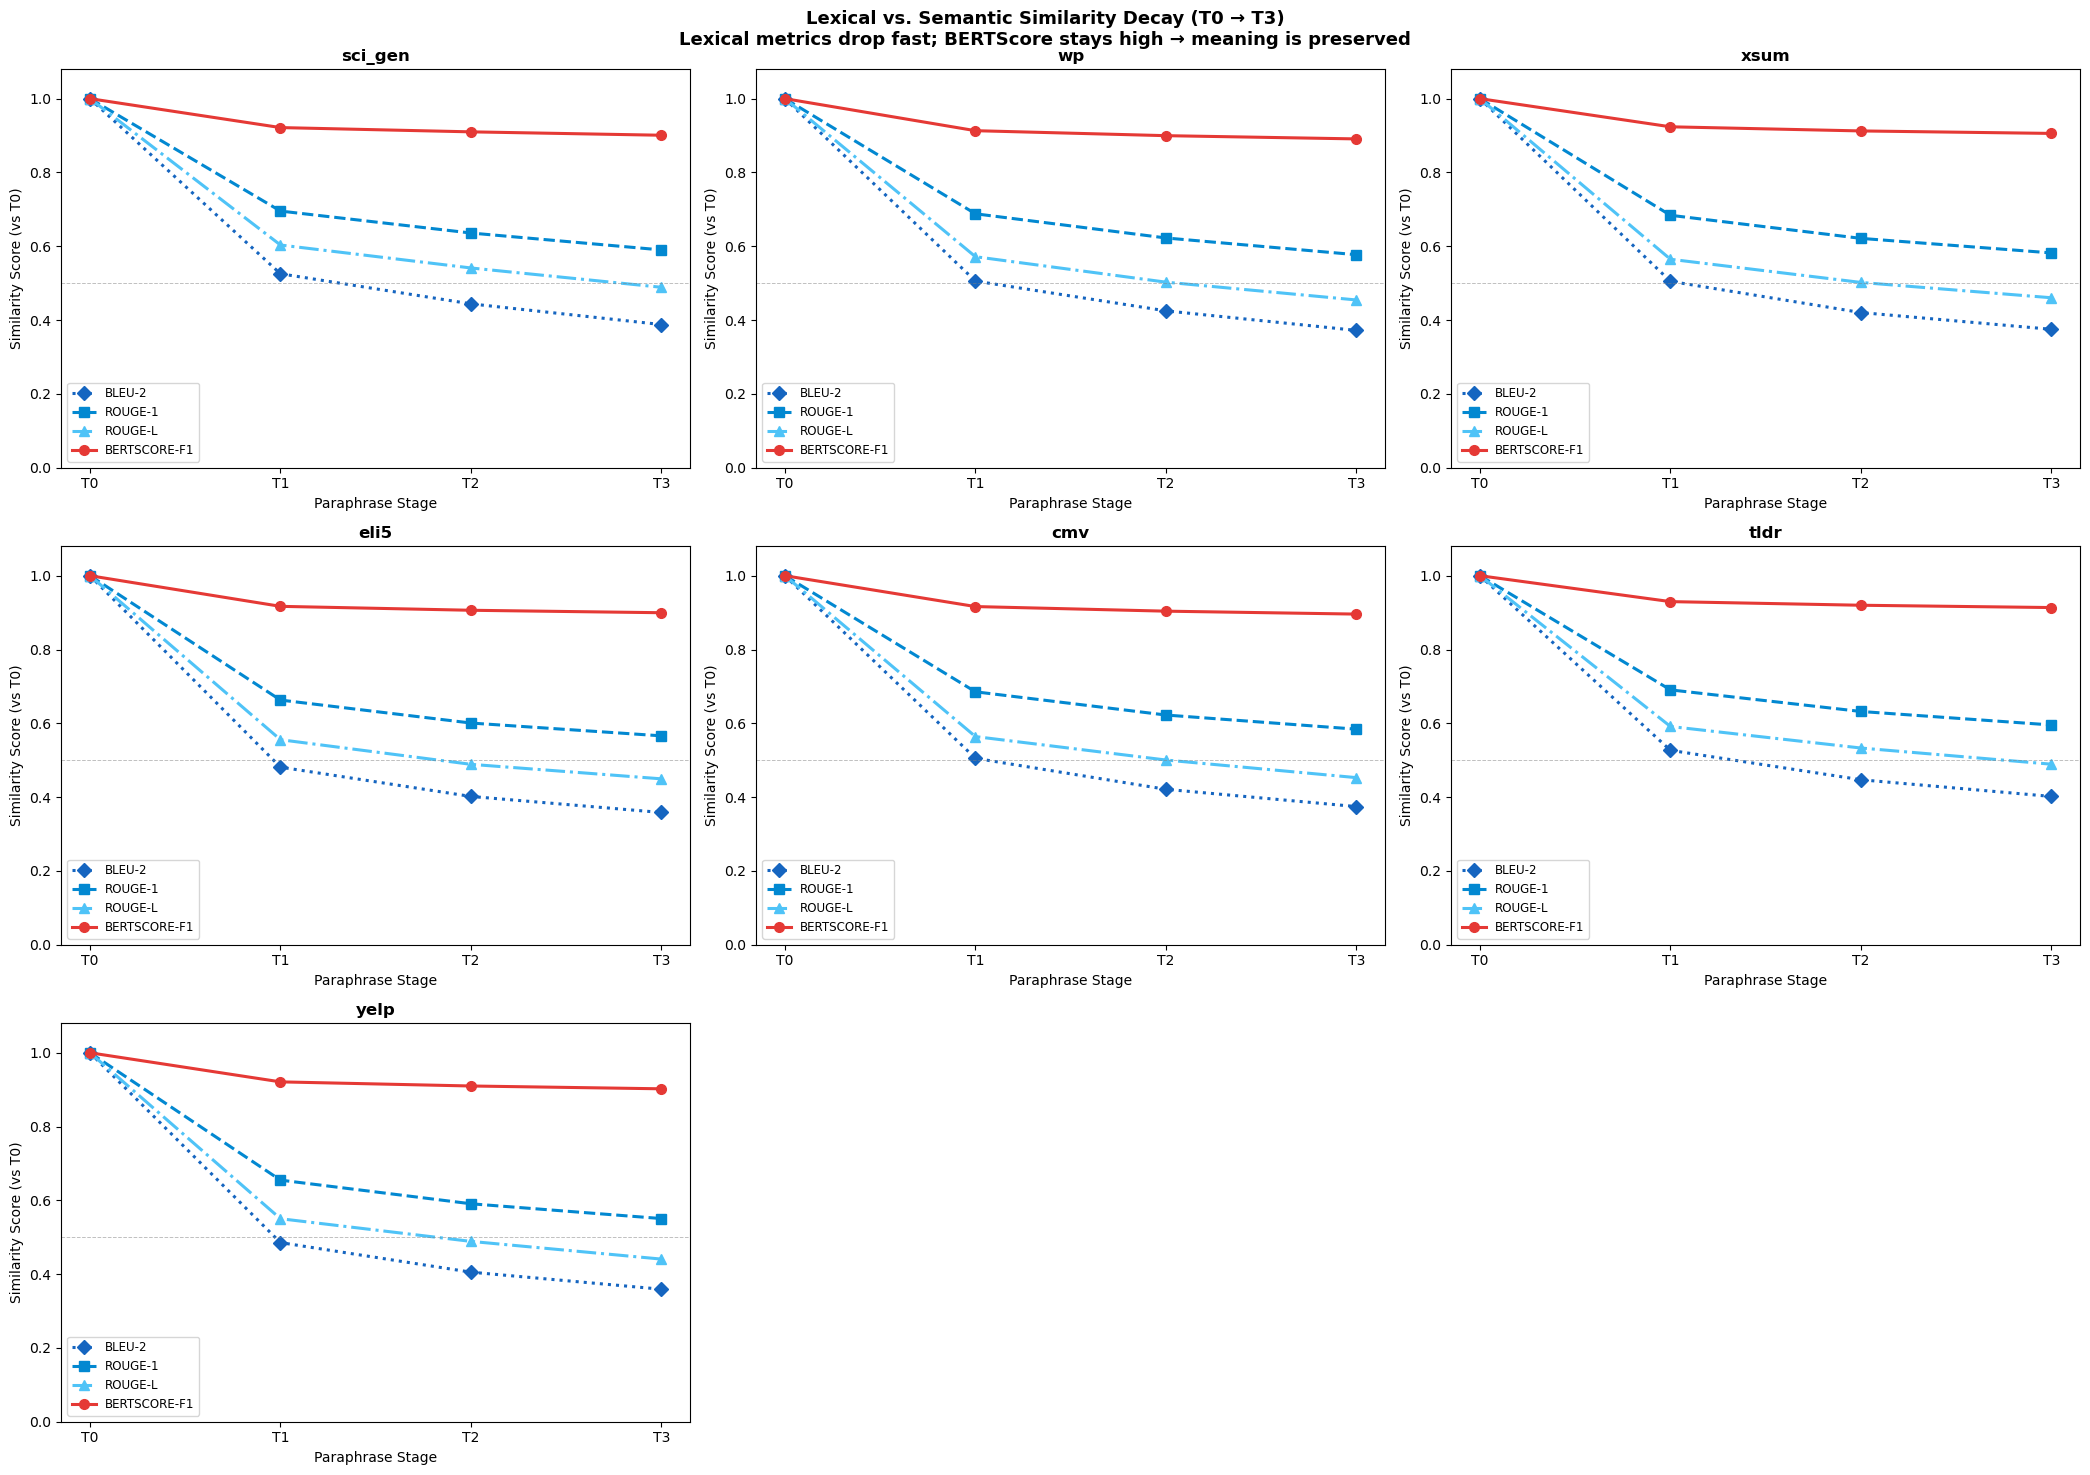

Saved: fig1_lexical_vs_semantic_decay.png


In [41]:
import math

datasets_list = list(scores.keys())
ncols = 3
nrows = math.ceil(len(datasets_list) / ncols)

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(7 * ncols, 5 * nrows),
                         sharey=False)
axes = axes.flatten()

METRIC_STYLE = {
    'BLEU-2':     {'color': '#1565C0', 'ls': ':',  'marker': 'D'},
    'ROUGE-1':    {'color': '#0288D1', 'ls': '--', 'marker': 's'},
    'ROUGE-L':    {'color': '#4FC3F7', 'ls': '-.', 'marker': '^'},
    'BERTSCORE-F1': {'color': '#E53935', 'ls': '-',  'marker': 'o'},
}
PLOT_STAGES = ['T1', 'T2', 'T3']

for ax, name in zip(axes, datasets_list):
    df = scores[name]
    lex  = mean_lex_scores(df)
    bert = mean_bertscore(df)
    
    combined = pd.concat([lex, bert], ignore_index=True)
    pivot = combined.pivot(index='metric', columns='stage', values='score')

    for metric, style in METRIC_STYLE.items():
        if metric not in pivot.index:
            print(f"WARNING: '{metric}' not found. Available: {pivot.index.tolist()}")
            continue
        vals = [1.0] + [pivot.loc[metric, s] if s in pivot.columns else np.nan
                        for s in PLOT_STAGES]
        ax.plot(STAGES, vals,
                color=style['color'], linestyle=style['ls'],
                marker=style['marker'], linewidth=2.2,
                markersize=7, label=metric)

    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Paraphrase Stage')
    ax.set_ylabel('Similarity Score (vs T0)')
    ax.set_ylim(0, 1.08)
    ax.axhline(0.5, color='grey', linewidth=0.7, linestyle='--', alpha=0.5)
    ax.legend(fontsize=8.5)

for ax in axes[len(datasets_list):]:
    ax.set_visible(False)

fig.suptitle('Lexical vs. Semantic Similarity Decay (T0 → T3)\n'
             'Lexical metrics drop fast; BERTScore stays high → meaning is preserved',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / 'fig1_lexical_vs_semantic_decay.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig1_lexical_vs_semantic_decay.png')

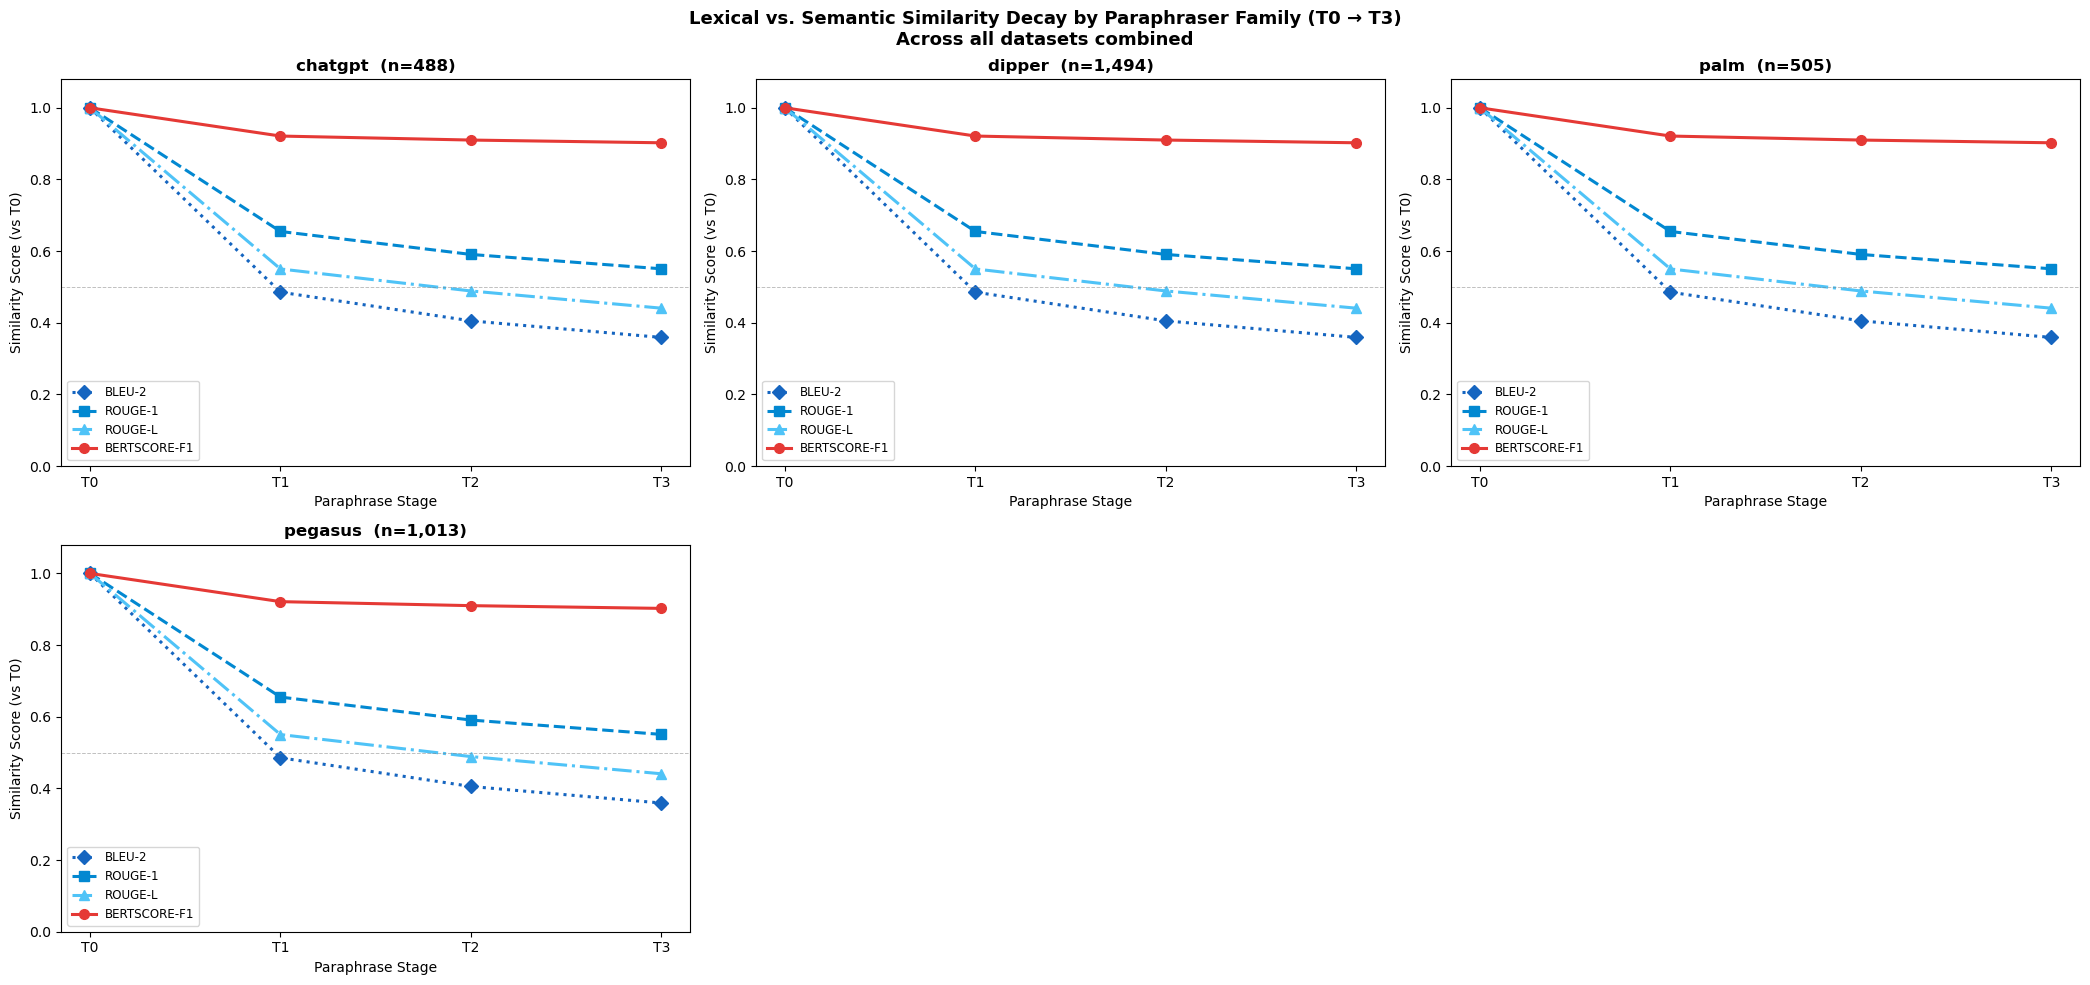

Saved: fig2_decay_by_family.png


In [42]:
import math

# Combine all datasets into one DataFrame
combined_all = pd.concat(scores.values(), ignore_index=True)
families = sorted(combined_all['family'].dropna().unique())

ncols = 3
nrows = math.ceil(len(families) / ncols)
fig, axes = plt.subplots(nrows, ncols,
                         figsize=(7 * ncols, 5 * nrows),
                         sharey=False)
axes = axes.flatten()

METRIC_STYLE = {
    'BLEU-2':       {'color': '#1565C0', 'ls': ':',  'marker': 'D'},
    'ROUGE-1':      {'color': '#0288D1', 'ls': '--', 'marker': 's'},
    'ROUGE-L':      {'color': '#4FC3F7', 'ls': '-.', 'marker': '^'},
    'BERTSCORE-F1': {'color': '#E53935', 'ls': '-',  'marker': 'o'},
}
PLOT_STAGES = ['T1', 'T2', 'T3']

for ax, family in zip(axes, families):
    # Filter combined data to just this paraphraser family
    df = combined_all[combined_all['family'] == family]

    lex  = mean_lex_scores(df)
    bert = mean_bertscore(df)
    
    for metric, style in METRIC_STYLE.items():
        if metric not in pivot.index:
            print(f"WARNING: '{metric}' not found. Available: {pivot.index.tolist()}")
            continue
        vals = [1.0] + [pivot.loc[metric, s] if s in pivot.columns else np.nan
                        for s in PLOT_STAGES]
        ax.plot(STAGES, vals,
                color=style['color'], linestyle=style['ls'],
                marker=style['marker'], linewidth=2.2,
                markersize=7, label=metric)

    ax.set_title(f"{family}  (n={len(df):,})", fontweight='bold')
    ax.set_xlabel('Paraphrase Stage')
    ax.set_ylabel('Similarity Score (vs T0)')
    ax.set_ylim(0, 1.08)
    ax.axhline(0.5, color='grey', linewidth=0.7, linestyle='--', alpha=0.5)
    ax.legend(fontsize=8.5)

for ax in axes[len(families):]:
    ax.set_visible(False)

fig.suptitle('Lexical vs. Semantic Similarity Decay by Paraphraser Family (T0 → T3)\n'
             'Across all datasets combined',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / 'fig1_decay_by_family.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig2_decay_by_family.png')